In [276]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


from sklearn.model_selection import train_test_split

In [277]:
#lese inn datasettet
df = pd.read_csv("persona_survey.csv")
print(df.head())

  persona_id            name  type          occupation occupation_category  \
0      f0000    Isaac Newton  real           physicist  science & medicine   
1      f0001    Donald Trump  real          politician     politics & rule   
2      f0002    Genghis Khan  real  military personnel            military   
3      f0003       Cleopatra  real          politician     politics & rule   
4      f0004  Mahatma Gandhi  real     social activist               other   

  gender    born    died                    born_city    born_country  ...  \
0      M  1643.0  1726.0  Woolsthorpe-by-Colsterworth  United Kingdom  ...   
1      M  1946.0     NaN                       Queens   United States  ...   
2      M  1162.0  1227.0            Khentii Mountains        Mongolia  ...   
3      F   -69.0   -30.0                   Alexandria           Egypt  ...   
4      M  1869.0  1948.0                    Porbandar           India  ...   

                         personal.last_meal  personal.favorite

In [278]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 74 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   persona_id                                      10000 non-null  object 
 1   name                                            10000 non-null  object 
 2   type                                            10000 non-null  object 
 3   occupation                                      9964 non-null   object 
 4   occupation_category                             9964 non-null   object 
 5   gender                                          9965 non-null   object 
 6   born                                            9965 non-null   float64
 7   died                                            7770 non-null   float64
 8   born_city                                       9499 non-null   object 
 9   born_country                            

# Datavalidering

In [279]:
manglende = df.isna().sum()
manglende = manglende[manglende > 0].sort_values(ascending=False) 
manglende


died                                    2230
born_city                                501
born_country                             324
personal.favorite_person                  47
occupation                                36
occupation_category                       36
gender                                    35
born                                      35
personal.favorite_painting                25
personal.favorite_book                    24
values.random_people_per_me               15
personal.favorite_animal                  15
values.wants_to_live_forever              15
values.p_living_in_simulation             15
values.p_god_exists                       15
values.free_will                          15
values.child_quality_most_important       15
values.friend_crime_testify               15
values.dictator_give_pct                  15
personal.last_meal                        12
personal.favorite_thing_about_bergen       9
personal.favorite_data_science_fact        9
personal.s

- Undersøker om de manglende radene i del 2 born og occupation_category overlapper


In [280]:
manglende_occ_cat = df["occupation_category"].isna()
manglende_born = df["born"].isna()
print('Mangler occupation_category:', manglende_occ_cat.sum())
print('Mangler born:', manglende_born.sum())
print('Mangler begge:', (manglende_occ_cat & manglende_born).sum())


Mangler occupation_category: 36
Mangler born: 35
Mangler begge: 35


- Fjerner tomme data
    - Fjerner alle tomme data i occupation_category fordi det overlapper fullt med de tomme dataene i born

In [281]:
df_renset = df.dropna(subset=["occupation_category"])

In [282]:
manglende_occ_cat = df_renset["occupation_category"].isna()
manglende_born = df_renset["born"].isna()
print('Mangler occupation_category:', manglende_occ_cat.sum())
print('Mangler born:', manglende_born.sum())
print('Mangler begge:', (manglende_occ_cat & manglende_born).sum())

Mangler occupation_category: 0
Mangler born: 0
Mangler begge: 0


# Trening og Testsplitting
- Å bruke stratify på occupation_category gjør at dataene bli gjevnt fordelt i trening, validering og test dataene

In [283]:
train, temp, = train_test_split(df_renset, test_size=0.3, random_state=42, stratify=df_renset["occupation_category"])
val, test, = train_test_split(temp, test_size=0.5, random_state=42, stratify=temp["occupation_category"])

# Utforskende analyser

## Big 5 
Beregning av big 5 personligetspoeng

In [284]:
def reverse(x):
    return 6 - x

# Legger sammen 
def legg_til_big_five(d):
    d = d.copy()
    d['EXT_score'] = d['big_five.EXT1'] + reverse(d['big_five.EXT2']) + d['big_five.EXT5'] + reverse(d['big_five.EXT10'])
    d['EST_score'] = d['big_five.EST1'] + reverse(d['big_five.EST2']) + d['big_five.EST3'] + d['big_five.EST10']
    d['AGR_score'] = reverse(d['big_five.AGR1']) + d['big_five.AGR2'] + d['big_five.AGR4'] + reverse(d['big_five.AGR5'])
    d['CSN_score'] = d['big_five.CSN1'] + reverse(d['big_five.CSN2']) + d['big_five.CSN5'] + reverse(d['big_five.CSN8'])
    d['OPN_score'] = reverse(d['big_five.OPN2']) + d['big_five.OPN3'] + reverse(d['big_five.OPN6']) + d['big_five.OPN9']
    return d

train = legg_til_big_five(train)
val   = legg_til_big_five(val)
test  = legg_til_big_five(test)

## politiske meninger
Beregning av politiske meninger

In [285]:
train['political_compass.econ_redistribute_wealth'].unique()

array(['agree', 'disagree', 'strongly agree', 'strongly disagree'],
      dtype=object)

In [286]:
likert_map = {
    'strongly disagree': -2,
    'disagree': -1,
    'agree': 1,
    'strongly agree': 2
}

In [287]:
def legg_til_politisk_kompass(d):
    d = d.copy()
    
    econ_venstre = [
        'political_compass.econ_redistribute_wealth',
        'political_compass.econ_public_services',
        'political_compass.econ_tax_the_wealthy'
    ]
    econ_høyre = [
        'political_compass.econ_free_markets',
        'political_compass.econ_personal_responsibility',
        'political_compass.econ_welfare_dependency'
    ]
    soc_libertær = [
        'political_compass.soc_immigration_benefits',
        'political_compass.soc_legalize_drugs',
        'political_compass.soc_embrace_changing_norms'
    ]
    soc_autoritær = [
        'political_compass.soc_strong_leader',
        'political_compass.soc_harsh_punishment',
        'political_compass.soc_traditional_values_laws'
    ]
    
    venstre_sum = d[econ_venstre].apply(lambda col: col.map(likert_map)).sum(axis=1)
    høyre_sum = d[econ_høyre].apply(lambda col: col.map(likert_map)).sum(axis=1)
    d['pc_econ'] = venstre_sum - høyre_sum  
     # positiv = venstre, negativ = høyre
    
    lib_sum = d[soc_libertær].apply(lambda col: col.map(likert_map)).sum(axis=1)
    aut_sum = d[soc_autoritær].apply(lambda col: col.map(likert_map)).sum(axis=1)
    d['pc_soc'] = lib_sum - aut_sum          
    # positiv = libertær, negativ = autoritær
    
    return d

train = legg_til_politisk_kompass(train)
val   = legg_til_politisk_kompass(val)
test  = legg_til_politisk_kompass(test)

### Bruker de sammenslåtte dataene 

#### Big 5 mot jobbtyper

- Sjekker ekstoverthet utifra typen jobb

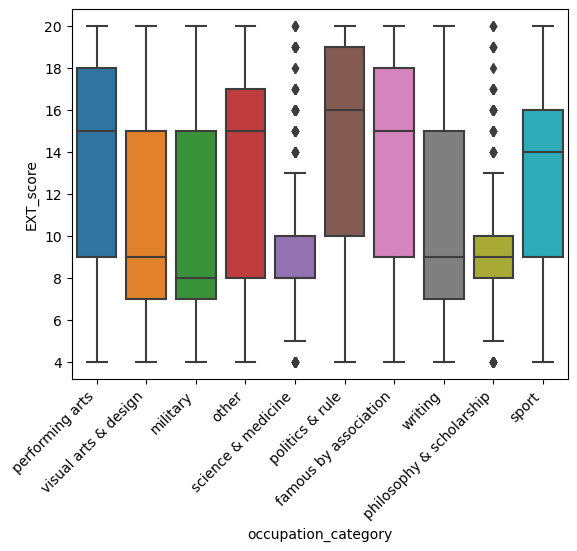

In [306]:
sns.boxplot(data=train, x='occupation_category', y='EXT_score')
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

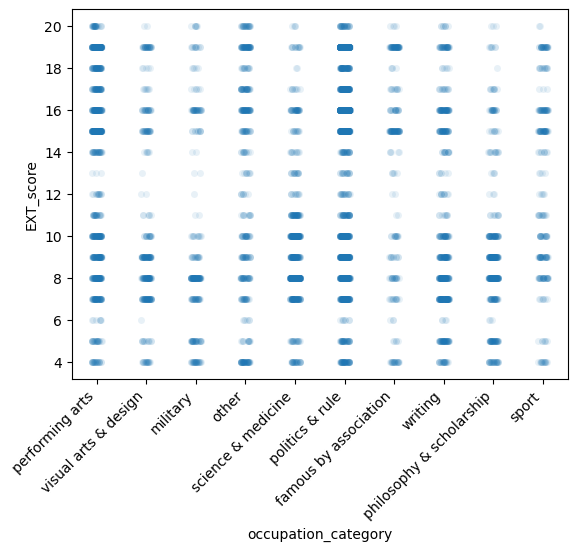

In [307]:
sns.stripplot(data=train, x='occupation_category', y='EXT_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

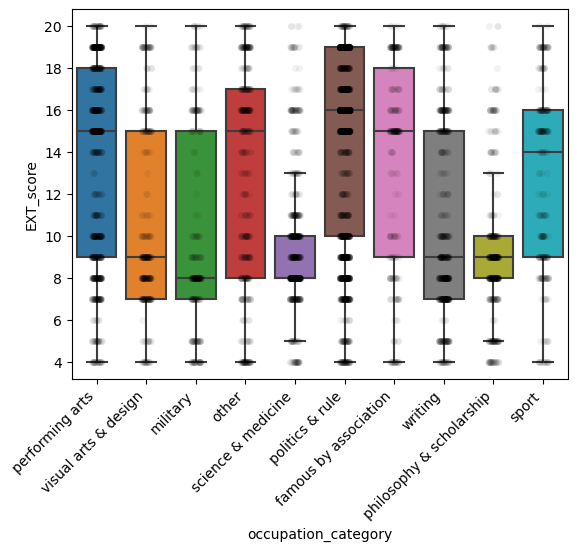

In [308]:
sns.boxplot(data=train, x='occupation_category', y='EXT_score', showfliers=False)
sns.stripplot(data=train, x='occupation_category', y='EXT_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Grafene viser at modellen lener seg på steritoyper av jobber, den tror for eksempel politics og rule og performing arts er mest ekstrovert. Den mener også at science og medicine og philosophy og scolarship er minst ekstrovert

- Sjekker nevtrotisisme utifra jobbtype

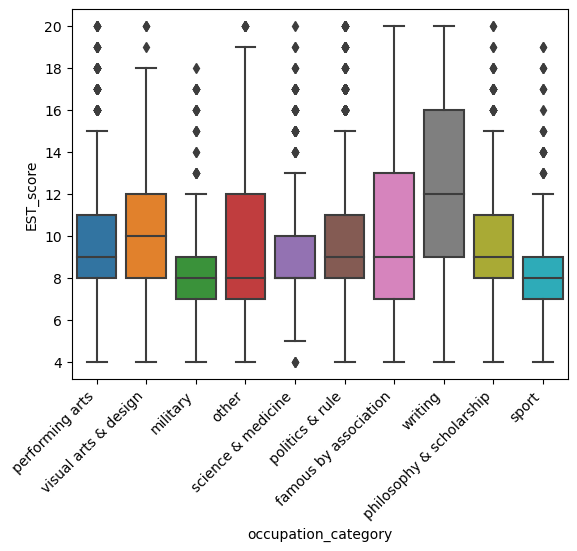

In [309]:
sns.boxplot(data=train, x='occupation_category', y='EST_score')
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

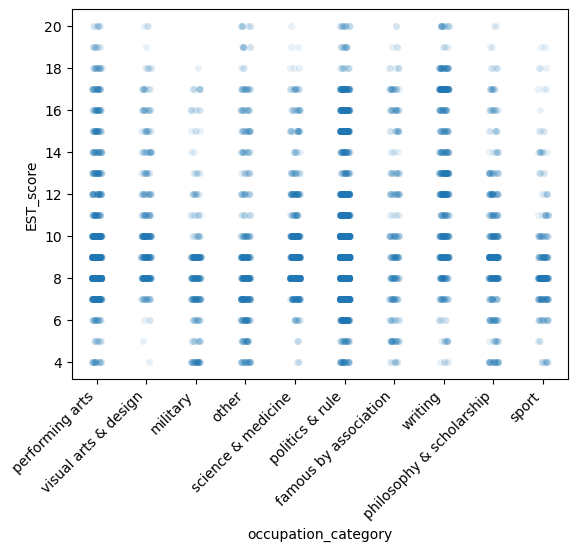

In [310]:
sns.stripplot(data=train, x='occupation_category', y='EST_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

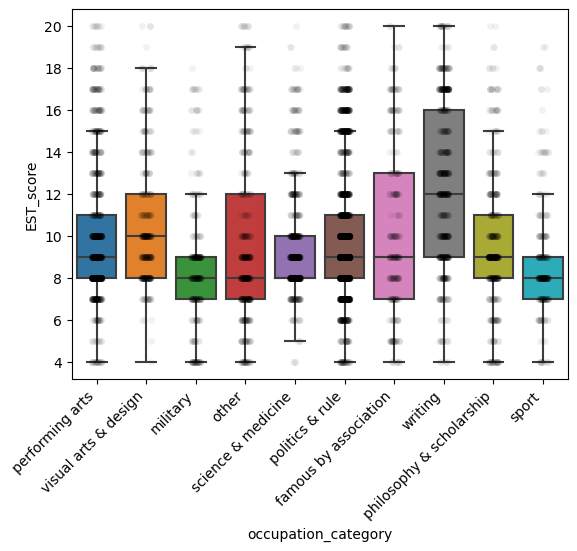

In [311]:
sns.boxplot(data=train, x='occupation_category', y='EST_score', showfliers=False)
sns.stripplot(data=train, x='occupation_category', y='EST_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her lener modellen igjen på steriotyper der writing er den høyeste kategorien. Her er det military og sport som scorerr lavest, dette lener igjen på steriotypene til den følelsesløse soldaten eller en typisk sportspiller en "jock"

- Sjekker omgjengelighet utifra jobbtype

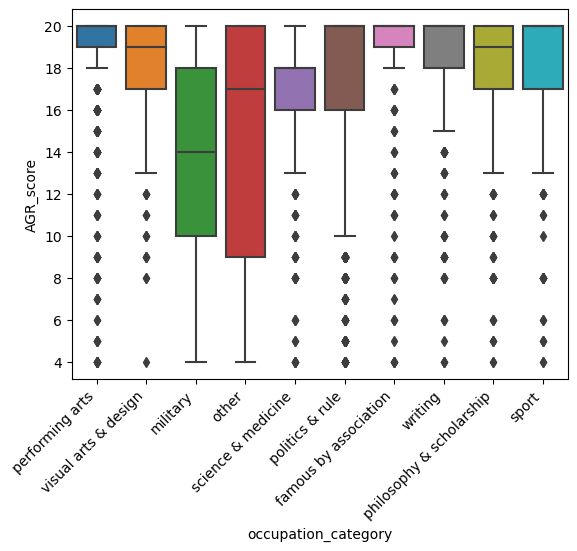

In [312]:
sns.boxplot(data=train, x='occupation_category', y='AGR_score')
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

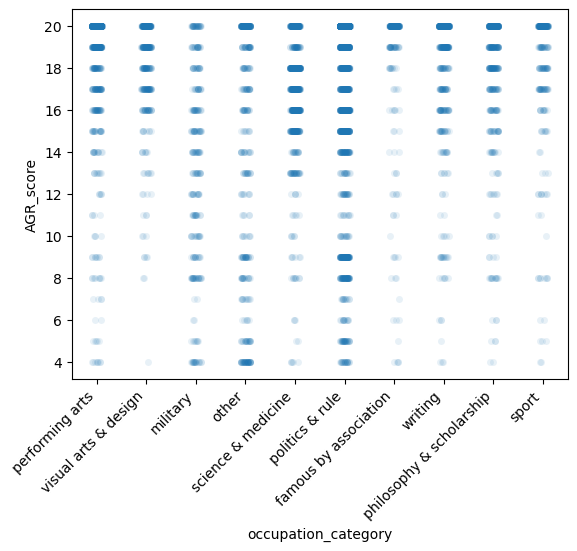

In [313]:
sns.stripplot(data=train, x='occupation_category', y='AGR_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

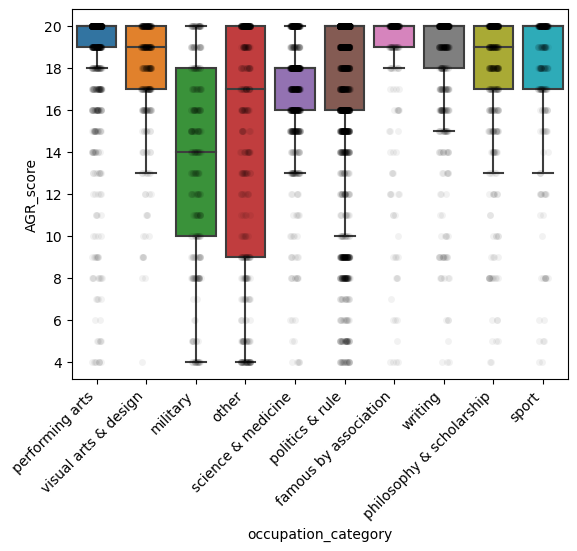

In [314]:
sns.boxplot(data=train, x='occupation_category', y='AGR_score', showfliers=False)
sns.stripplot(data=train, x='occupation_category', y='AGR_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her er det et klart skifte, de fleste yrkene lener seg mot en veldig høy score i omgjengeliget. Det er en ganske stor spredning i military og other med noen som har veldig lav score, men generelt har alle en høy score.

- Sjekker planmessighet utifra jobbtype

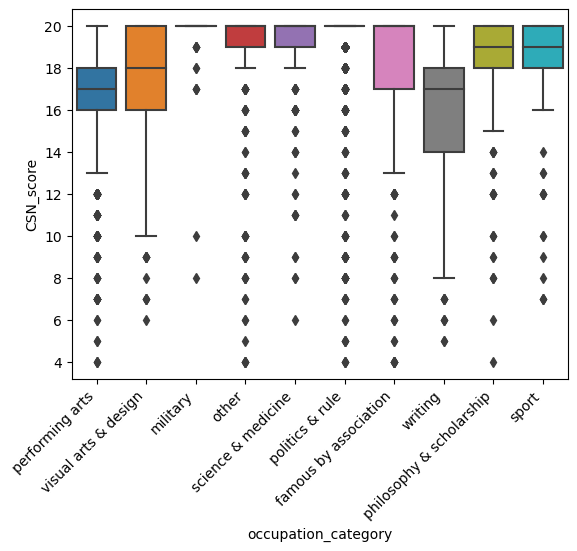

In [315]:
sns.boxplot(data=train, x='occupation_category', y='CSN_score')
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

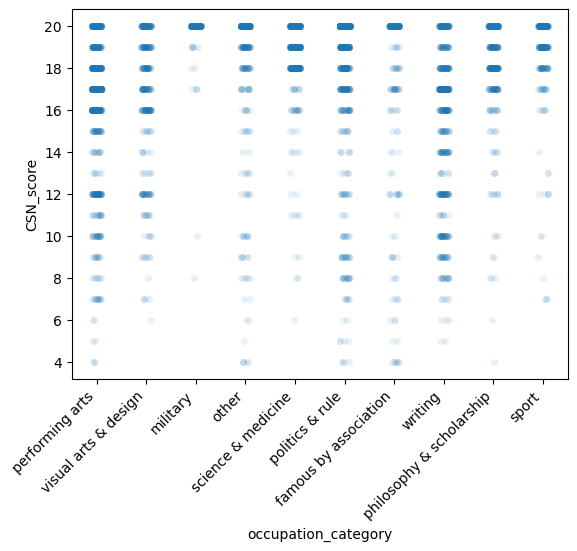

In [316]:
sns.stripplot(data=train, x='occupation_category', y='CSN_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

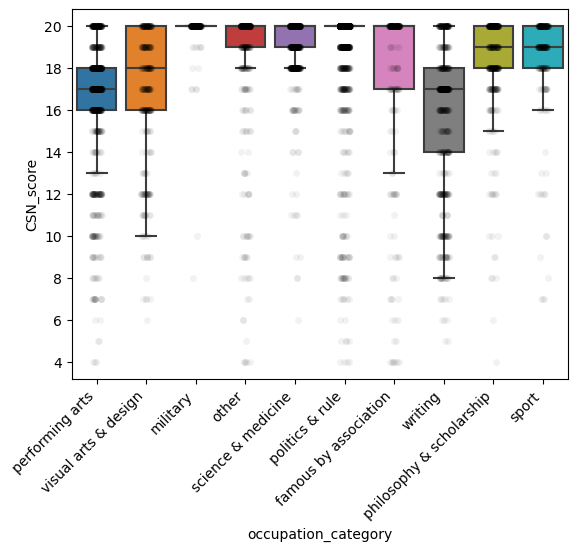

In [317]:
sns.boxplot(data=train, x='occupation_category', y='CSN_score', showfliers=False)
sns.stripplot(data=train, x='occupation_category', y='CSN_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her lener modellen også en veldig høy score i planmessighet, men den bruker noen steriotyper, millitary har nesten bare toppscore og politikk og rule har også en veldig høy score. Writing har litt lavere score men der også er medianen på rundt 17 som er veldig høyt.

- Sjekker åpenhet mot jobbtype

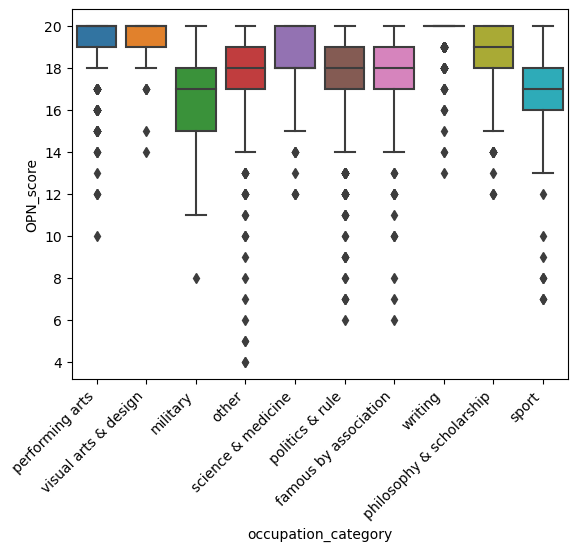

In [318]:
sns.boxplot(data=train, x='occupation_category', y='OPN_score')
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

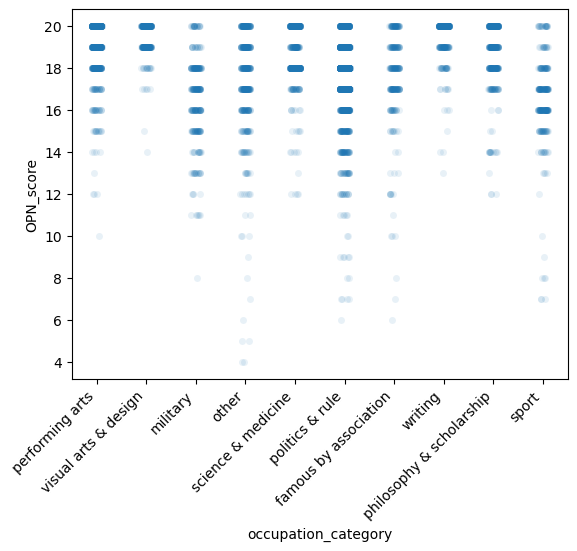

In [319]:
sns.stripplot(data=train, x='occupation_category', y='OPN_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

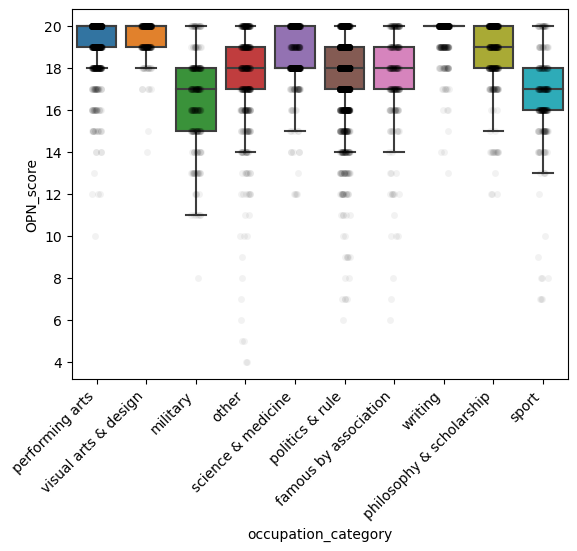

In [320]:
sns.boxplot(data=train, x='occupation_category', y='OPN_score', showfliers=False)
sns.stripplot(data=train, x='occupation_category', y='OPN_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her er det også generelt høy score. Witing er mest åpen som igjen lener på en steriotype, og millitary er litt mer tilbakeholden enn de andre men har fremdeles generelt en veldig høy score.

#### Politisk retning mot jobbtyper

- politisk økonomisk retning utifra jobbtyper

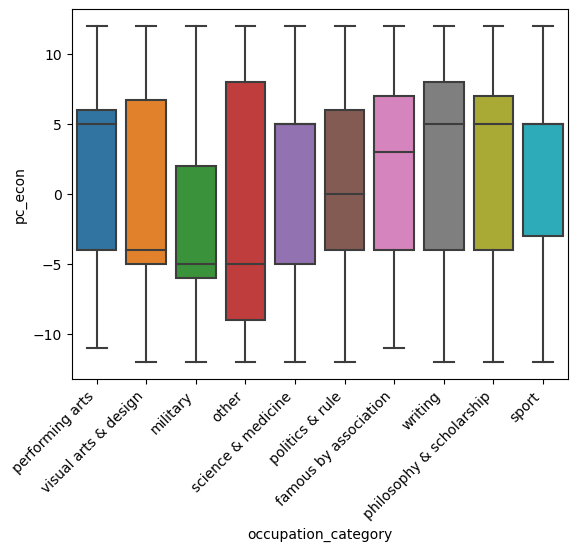

In [321]:
sns.boxplot(data=train, x='occupation_category', y='pc_econ')
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

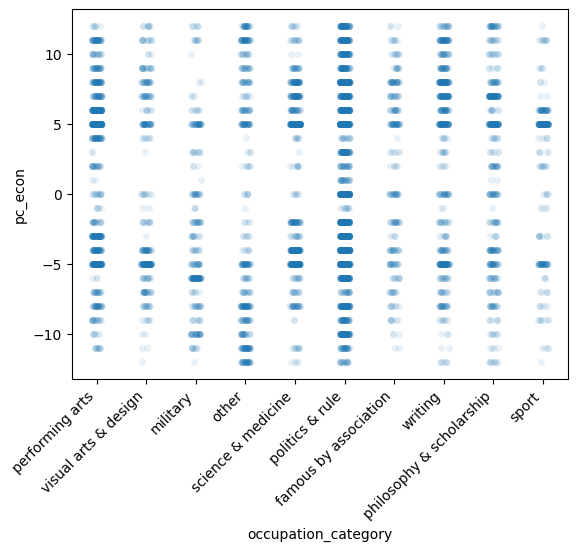

In [322]:
sns.stripplot(data=train, x='occupation_category', y='pc_econ', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

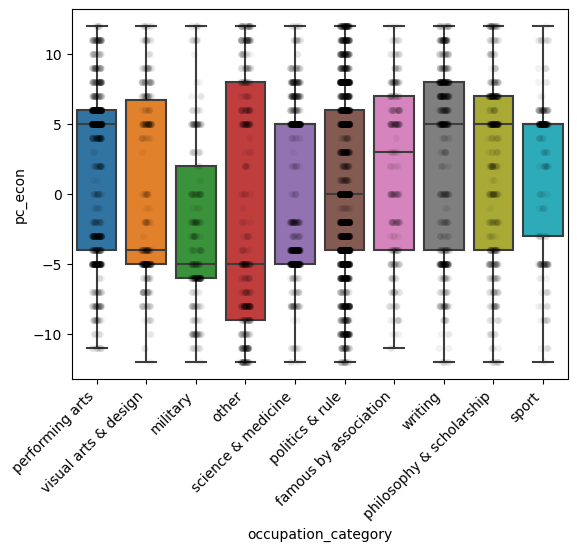

In [323]:
sns.boxplot(data=train, x='occupation_category', y='pc_econ', showfliers=False)
sns.stripplot(data=train, x='occupation_category', y='pc_econ', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her er resultatene mer spredt, noe som tyder på at modellen ikke har like sterke antagelser på hvor hver person lener. Den har fremdeles noen steriotyper her, for eksempel at military lener mer mot høyre og at writing, performing arts og philosophy og scolarship lener mer mot venstre.

- politisk retning mot jobbtype

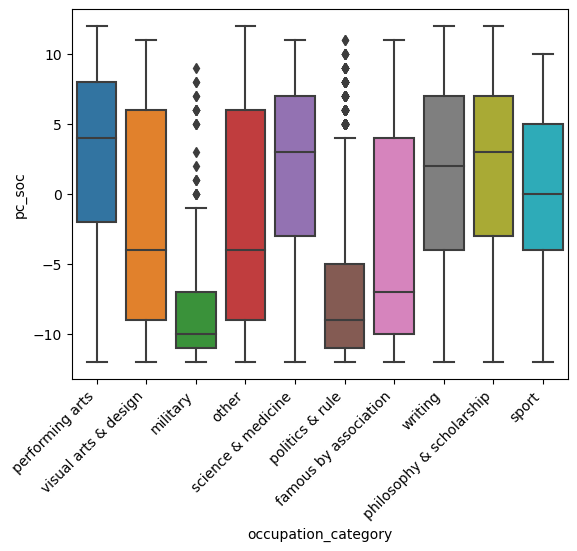

In [327]:
sns.boxplot(data=train, x='occupation_category', y='pc_soc')
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

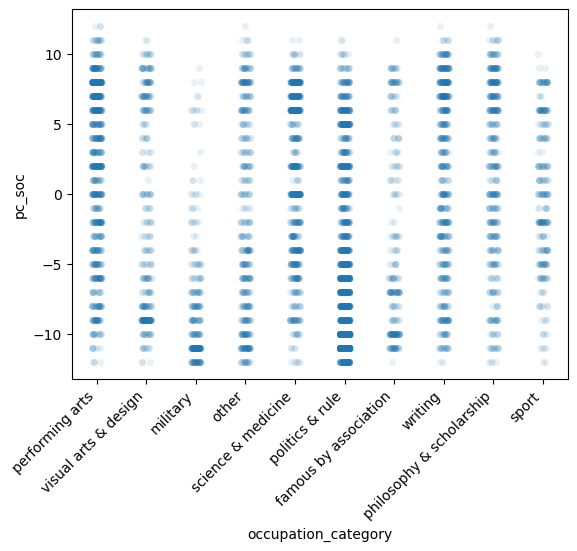

In [328]:
sns.stripplot(data=train, x='occupation_category', y='pc_soc', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

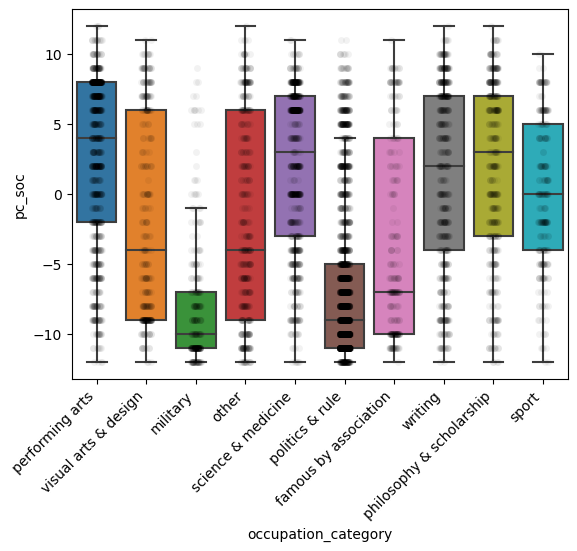

In [329]:
sns.boxplot(data=train, x='occupation_category', y='pc_soc', showfliers=False)
sns.stripplot(data=train, x='occupation_category', y='pc_soc', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her følger modellen også de samme steriotypene, military og politics og rule er mer autoritær, mens det er mer spredning i de andre kategoriene. Det er interesannt at selv de kategoriene som lener seg mot liberal siden er ikke like tydelig som de som er klart autoritær, noe som kan tyde på at modellen enten er litt usikker eller lener seg selv litt mot autoritæritet.

## Tidstrender